In [20]:
import sys

print(sys.executable)

/home/patzer_adi/Documents/patent_intelligence/.venv/bin/python


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datasets 
import pyarrow

In [22]:
from datasets import load_dataset
from datasets import load_from_disk
print("Hugging Face datasets: OK")

Hugging Face datasets: OK


In [23]:
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 3.0.5
NumPy: 2.5.2


In [24]:
dataset = load_from_disk("../data/sample_dataset")
dataset

DatasetDict({
    train: Dataset({
        features: ['patent_number', 'decision', 'title', 'abstract', 'claims', 'background', 'summary', 'description', 'cpc_label', 'ipc_label', 'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],
        num_rows: 16153
    })
    validation: Dataset({
        features: ['patent_number', 'decision', 'title', 'abstract', 'claims', 'background', 'summary', 'description', 'cpc_label', 'ipc_label', 'filing_date', 'patent_issue_date', 'date_published', 'examiner_id'],
        num_rows: 9094
    })
})

In [25]:
train_df = dataset["train"].to_pandas()
test_df = dataset["validation"].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (16153, 14)
Test shape: (9094, 14)


In [26]:
train_df.iloc[0]

patent_number                                                 13261748
decision                                                      ACCEPTED
title                              MINI-OPTICAL NETWORK TERMINAL (ONT)
abstract             The present invention relates to passive optic...
claims               1. A compact optical network terminal, compris...
background           <SOH> BACKGROUND OF THE INVENTION <EOH>A netwo...
summary              <SOH> SUMMARY OF THE INVENTION <EOH>An aspect ...
description          FIELD OF THE INVENTION The present invention r...
cpc_label                                                   H04Q110071
ipc_label                                                     H04Q1100
filing_date                                                   20160120
patent_issue_date                                             20170606
date_published                                                20160526
examiner_id                                                    95191.0
Name: 

In [27]:
print("TITLE:")
print(train_df.loc[0, "title"])

print("\nABSTRACT:")
print(train_df.loc[0, "abstract"])

print("\nCLAIMS:")
print(train_df.loc[0, "claims"])

TITLE:
MINI-OPTICAL NETWORK TERMINAL (ONT)

ABSTRACT:
The present invention relates to passive optical network (PON), and in particular, to an optical network terminal (ONT) in the PON system. In one embodiment, the optical network terminal includes a first interface coupled to a communications network, a second interface coupled to a network client and a processor including a memory coupled to the first interface and to the second interface, wherein the processor is capable of converting optical signals to electric signals, such that the network client can access the communications network.

CLAIMS:
1. A compact optical network terminal, comprising: a first interface coupled to a communications network; a second interface coupled to a network client, wherein the second interface is a network connectivity dongle with an optical transceiver at one end; and a processor including a circuitry and a memory coupled to the first interface and to the second interface, wherein the processor is 

In [28]:
text_columns = [
    "title",
    "abstract",
    "claims",
    "background",
    "summary",
    "description"
]

train_df[text_columns].dtypes

title          str
abstract       str
claims         str
background     str
summary        str
description    str
dtype: object

In [29]:
text_columns = [
    "title",
    "abstract",
    "claims",
    "background",
    "summary",
    "description"
]

text_stats = {}

for col in text_columns:
    print(f"Processing: {col}")

    chars = train_df[col].fillna("").str.len()
    words = train_df[col].fillna("").str.count(r"\S+")

    text_stats[col] = {
        "mean_chars": chars.mean(),
        "median_chars": chars.median(),
        "max_chars": chars.max(),
        "mean_words": words.mean(),
        "median_words": words.median(),
        "max_words": words.max(),
    }

    del chars
    del words

Processing: title
Processing: abstract
Processing: claims
Processing: background
Processing: summary
Processing: description


In [30]:
text_stats_df = pd.DataFrame(text_stats).T

text_stats_df

,mean_chars,median_chars,max_chars,mean_words,median_words,max_words
title,57.922739,53.0,495.0,7.840215,7.0,56.0
abstract,688.291649,703.0,3174.0,109.285458,112.0,510.0
claims,6135.324212,5378.0,134792.0,982.316288,868.0,20111.0
background,2588.132793,1785.0,102113.0,404.573206,277.0,15814.0
summary,4969.844301,2858.0,268652.0,791.099115,454.0,38940.0
description,58566.155203,42872.0,2016366.0,9384.804309,6977.0,400946.0


In [31]:
for col in text_columns:
    print("\n" + "="*50)
    print(col.upper())
    print("="*50)

    s = train_df[col].fillna("")

    chars = s.str.len()
    words = s.str.count(r"\S+")

    print("Mean characters:   ", chars.mean())
    print("Median characters: ", chars.median())
    print("95th percentile:   ", chars.quantile(0.95))
    print("Maximum characters:", chars.max())

    print("Mean words:        ", words.mean())
    print("Median words:      ", words.median())
    print("95th percentile:  ", words.quantile(0.95))
    print("Maximum words:     ", words.max())

    del s
    del chars
    del words


TITLE
Mean characters:    57.92273881012815
Median characters:  53.0
95th percentile:    114.0
Maximum characters: 495
Mean words:         7.840215439856373
Median words:       7.0
95th percentile:   16.0
Maximum words:      56

ABSTRACT
Mean characters:    688.2916486101653
Median characters:  703.0
95th percentile:    1033.0
Maximum characters: 3174
Mean words:         109.28545780969479
Median words:       112.0
95th percentile:   160.0
Maximum words:      510

CLAIMS
Mean characters:    6135.32421222064
Median characters:  5378.0
95th percentile:    12572.799999999997
Maximum characters: 134792
Mean words:         982.3162879960379
Median words:       868.0
95th percentile:   2005.0
Maximum words:      20111

BACKGROUND
Mean characters:    2588.1327926700924
Median characters:  1785.0
95th percentile:    7548.799999999999
Maximum characters: 102113
Mean words:         404.5732062155637
Median words:       277.0
95th percentile:   1193.3999999999996
Maximum words:      15814

SUMMA

In [32]:
thresholds = {
    "1,000 words": 1000,
    "2,000 words": 2000,
    "5,000 words": 5000,
    "10,000 words": 10000,
    "20,000 words": 20000,
    "50,000 words": 50000,
    "100,000 words": 100000
}

for col in text_columns:
    print("\n" + "=" * 50)
    print(col.upper())
    print("=" * 50)

    words = train_df[col].fillna("").str.count(r"\S+")

    for label, threshold in thresholds.items():
        count = (words > threshold).sum()
        percentage = count / len(train_df) * 100

        print(f">{label}: {count:,} ({percentage:.2f}%)")

    del words


TITLE
>1,000 words: 0 (0.00%)
>2,000 words: 0 (0.00%)
>5,000 words: 0 (0.00%)
>10,000 words: 0 (0.00%)
>20,000 words: 0 (0.00%)
>50,000 words: 0 (0.00%)
>100,000 words: 0 (0.00%)

ABSTRACT
>1,000 words: 0 (0.00%)
>2,000 words: 0 (0.00%)
>5,000 words: 0 (0.00%)
>10,000 words: 0 (0.00%)
>20,000 words: 0 (0.00%)
>50,000 words: 0 (0.00%)
>100,000 words: 0 (0.00%)

CLAIMS
>1,000 words: 6,205 (38.41%)
>2,000 words: 819 (5.07%)
>5,000 words: 31 (0.19%)
>10,000 words: 4 (0.02%)
>20,000 words: 1 (0.01%)
>50,000 words: 0 (0.00%)
>100,000 words: 0 (0.00%)

BACKGROUND
>1,000 words: 1,183 (7.32%)
>2,000 words: 242 (1.50%)
>5,000 words: 14 (0.09%)
>10,000 words: 1 (0.01%)
>20,000 words: 0 (0.00%)
>50,000 words: 0 (0.00%)
>100,000 words: 0 (0.00%)

SUMMARY
>1,000 words: 3,755 (23.25%)
>2,000 words: 1,335 (8.26%)
>5,000 words: 200 (1.24%)
>10,000 words: 28 (0.17%)
>20,000 words: 9 (0.06%)
>50,000 words: 0 (0.00%)
>100,000 words: 0 (0.00%)

DESCRIPTION
>1,000 words: 16,109 (99.73%)
>2,000 words: 15,62

In [33]:
description_words = (
    train_df["description"]
    .fillna("")
    .str.count(r"\S+")
)

train_df.loc[
    description_words.nlargest(10).index,
    ["patent_number", "title"]
].assign(
    description_words=description_words.nlargest(10)
)

,patent_number,title,description_words
10892,14994503,"ENCODING METHOD, AND DECODING METHOD",400946
2798,14905310,CYANOTRIAZOLE COMPOUNDS,197839
4628,14987328,MODIFIED POLYNUCLEOTIDES FOR THE PRODUCTION OF...,159434
2254,14904758,"ISOLATED POLYNUCLEOTIDES AND POLYPEPTIDES, AND...",154947
579,14903024,Combinations of Hepatitis C Virus Inhibitors,149640
1365,14903841,TETRAZOLINONE COMPOUNDS AND APPLICATIONS THEREOF,133991
9091,14992475,TISSUE THICKNESS COMPENSATOR COMPRISING A RESE...,130551
10283,14993819,SYSTEMS AND METHODS FOR NONINVASIVE BLOOD GLUC...,122460
10361,14993905,SYSTEMS AND METHODS FOR GENERATING AND USING P...,122449
10293,14993830,SYSTEMS AND METHODS FOR COLLISION COMPUTING FO...,122414


In [34]:
description_words = (
    train_df["description"]
    .fillna("")
    .str.count(r"\S+")
)

top_indices = description_words.nlargest(5).index

for idx in top_indices:
    text = train_df.loc[idx, "description"]

    print("=" * 80)
    print("Patent number:", train_df.loc[idx, "patent_number"])
    print("Title:", train_df.loc[idx, "title"])
    print("Description words:", description_words.loc[idx])

    print("\n--- START OF DESCRIPTION ---")
    print(text[:2000])

    print("\n--- END OF DESCRIPTION ---")
    print(text[-2000:])
    print()

Patent number: 14994503
Title: ENCODING METHOD, AND DECODING METHOD
Description words: 400946

--- START OF DESCRIPTION ---
BACKGROUND OF INVENTION 1. Technical Field This application is based on application No. 2011-010909 filed in Japan on Jan. 21, 2011, on application No. 2011-061161 filed in Japan on Mar. 18, 2011, on application No. 2011-097671 filed in Japan on Apr. 25, 2011, on application No. 2011-164261 filed in Japan on Jul. 27, 2011, and on application No. 2011-250401 filed in Japan on Nov. 16, 2011, the content of which is hereby incorporated by reference. The present invention relates to an encoding method, a decoding method, an encoder, and a decoder using low-density parity check convolutional codes (LDPC-CC) supporting a plurality of coding rates. 2. Background Art In recent years, attention has been attracted to a low-density parity-check (LDPC) code as an error correction code that provides high error correction capability with a feasible circuit scale. Because of its

In [35]:
title_words = (
    train_df["title"]
    .fillna("")
    .str.count(r"\S+")
)

print(title_words.describe())

count    16153.000000
mean         7.840215
std          4.421125
min          1.000000
25%          5.000000
50%          7.000000
75%         10.000000
max         56.000000
Name: title, dtype: float64


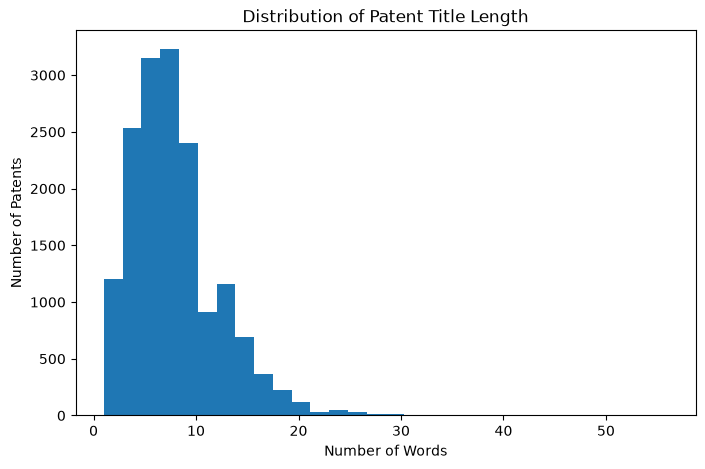

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(title_words, bins=30)

plt.title("Distribution of Patent Title Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Patents")

plt.show()

In [37]:
abstract_words = (
    train_df["abstract"]
    .fillna("")
    .str.count(r"\S+")
)

print(abstract_words.describe())

count    16153.000000
mean       109.285458
std         40.933096
min          6.000000
25%         80.000000
50%        112.000000
75%        140.000000
max        510.000000
Name: abstract, dtype: float64


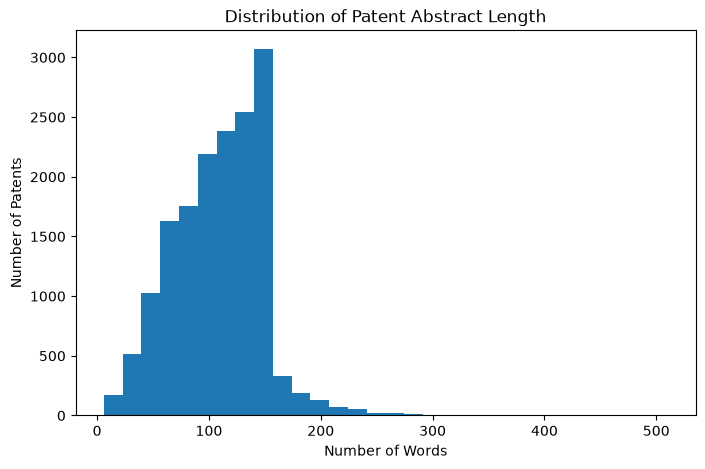

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(abstract_words, bins=30)

plt.title("Distribution of Patent Abstract Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Patents")

plt.show()

In [41]:
word_counts = []

for col in text_columns:
    words = train_df[col].fillna("").str.count(r"\S+")
    word_counts.append(words)
    del words

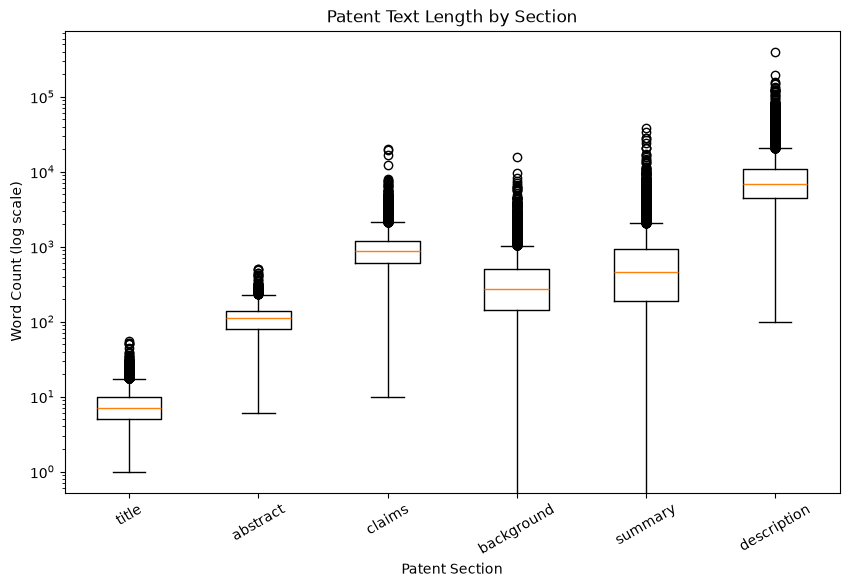

In [43]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    word_counts,
    tick_labels=text_columns
)

plt.yscale("log")

plt.title("Patent Text Length by Section")
plt.xlabel("Patent Section")
plt.ylabel("Word Count (log scale)")

plt.xticks(rotation=30)

plt.show()

In [44]:
for col in text_columns:

    words = train_df[col].fillna("").str.count(r"\S+")

    q1 = words.quantile(0.25)
    q3 = words.quantile(0.75)
    iqr = q3 - q1

    upper_bound = q3 + 1.5 * iqr

    outliers = words > upper_bound

    print("=" * 50)
    print(col.upper())
    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)
    print("Upper bound:", upper_bound)
    print("Outliers:", outliers.sum())
    print("Outlier %:", round(outliers.mean() * 100, 2))

    del words

TITLE
Q1: 5.0
Q3: 10.0
IQR: 5.0
Upper bound: 17.5
Outliers: 505
Outlier %: 3.13
ABSTRACT
Q1: 80.0
Q3: 140.0
IQR: 60.0
Upper bound: 230.0
Outliers: 112
Outlier %: 0.69
CLAIMS
Q1: 605.0
Q3: 1210.0
IQR: 605.0
Upper bound: 2117.5
Outliers: 640
Outlier %: 3.96
BACKGROUND
Q1: 142.0
Q3: 501.0
IQR: 359.0
Upper bound: 1039.5
Outliers: 1086
Outlier %: 6.72
SUMMARY
Q1: 191.0
Q3: 946.0
IQR: 755.0
Upper bound: 2078.5
Outliers: 1249
Outlier %: 7.73
DESCRIPTION
Q1: 4454.0
Q3: 10939.0
IQR: 6485.0
Upper bound: 20666.5
Outliers: 1122
Outlier %: 6.95


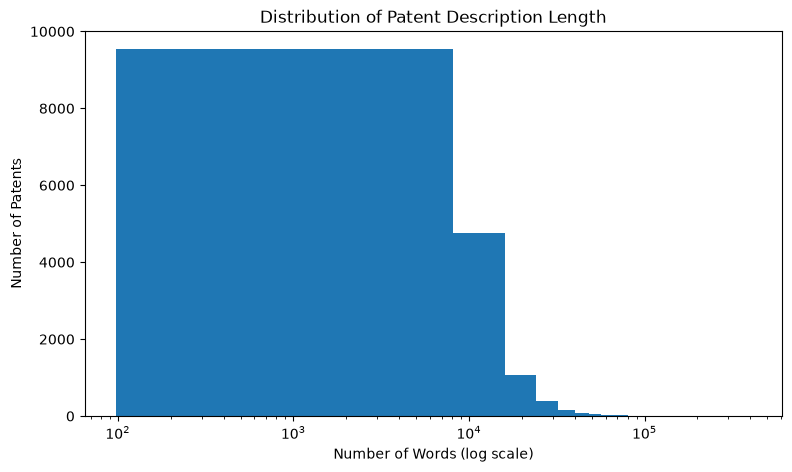

In [45]:
description_words = (
    train_df["description"]
    .fillna("")
    .str.count(r"\S+")
)

plt.figure(figsize=(9, 5))

plt.hist(description_words, bins=50)

plt.xscale("log")

plt.title("Distribution of Patent Description Length")
plt.xlabel("Number of Words (log scale)")
plt.ylabel("Number of Patents")

plt.show()

In [46]:
ipc_counts = train_df["ipc_label"].value_counts()

print("Unique IPC labels:", train_df["ipc_label"].nunique())
print("\nTop 20 IPC labels:")
print(ipc_counts.head(20))

Unique IPC labels: 6698

Top 20 IPC labels:
ipc_label
H04L2906     241
G06F1730     235
G06F306      124
H04L2908     107
G06F1900      83
A61B500       79
G06Q3002      79
H04W7204      68
G06F3041      67
C12Q168       63
G06K900       62
G06T700       62
H04N5232      61
H04L1224      59
G09G336       57
G06F1750      56
H04N100       47
H01L27146     45
G06F30484     45
G06Q1006      44
Name: count, dtype: int64


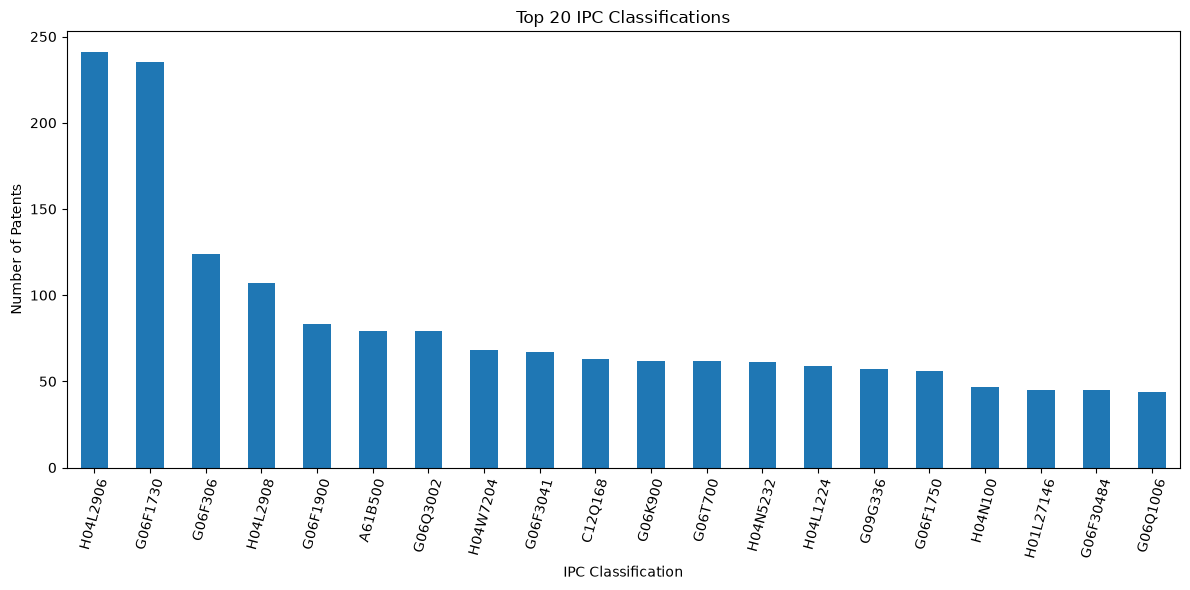

In [47]:
plt.figure(figsize=(12, 6))

ipc_counts.head(20).plot(kind="bar")

plt.title("Top 20 IPC Classifications")
plt.xlabel("IPC Classification")
plt.ylabel("Number of Patents")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [48]:
print(ipc_counts.describe())

count    6698.000000
mean        2.411615
std         6.312434
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       241.000000
Name: count, dtype: float64


In [49]:
print("IPC labels appearing once:",
      (ipc_counts == 1).sum())

print("IPC labels appearing <= 5 times:",
      (ipc_counts <= 5).sum())

print("IPC labels appearing > 100 times:",
      (ipc_counts > 100).sum())

IPC labels appearing once: 4307
IPC labels appearing <= 5 times: 6260
IPC labels appearing > 100 times: 4


In [50]:
for n in [10, 20, 50, 100]:
    coverage = ipc_counts.head(n).sum() / len(train_df) * 100
    print(f"Top {n} IPC labels cover {coverage:.2f}% of patents")

Top 10 IPC labels cover 7.09% of patents
Top 20 IPC labels cover 10.43% of patents
Top 50 IPC labels cover 16.54% of patents
Top 100 IPC labels cover 22.93% of patents


In [51]:
cpc_counts = train_df["cpc_label"].value_counts()

print("Unique CPC labels:", train_df["cpc_label"].nunique())

print("\nTop 20 CPC labels:")
print(cpc_counts.head(20))

Unique CPC labels: 10323

Top 20 CPC labels:
cpc_label
G06F30416      29
G06F3044       27
G06F3017       21
G06F945558     20
G06T19006      20
G06F304847     20
H04W76023      19
G06F173053     18
H01L2711582    18
G06F3061       17
G06F1730598    17
C07D47104      17
B29C670088     17
H04L630428     17
H01L27124      16
C12N15113      15
C07D48704      15
H04L6308       15
H04L671097     15
G02F1134309    15
Name: count, dtype: int64


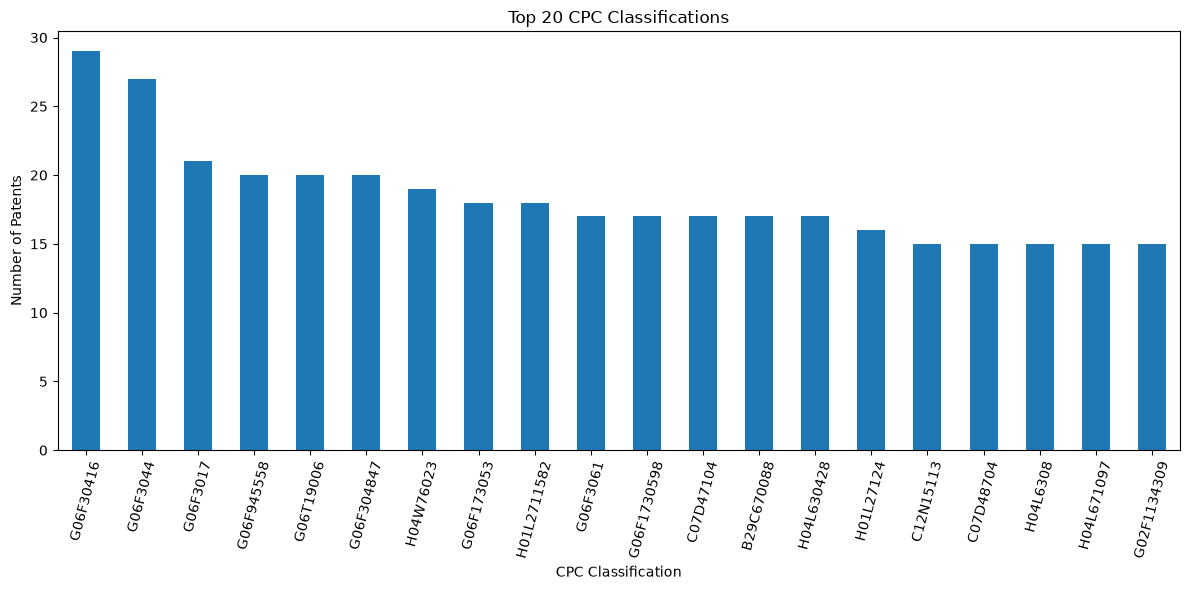

In [52]:
plt.figure(figsize=(12, 6))

cpc_counts.head(20).plot(kind="bar")

plt.title("Top 20 CPC Classifications")
plt.xlabel("CPC Classification")
plt.ylabel("Number of Patents")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [53]:
print(cpc_counts.describe())

count    10323.000000
mean         1.564758
std          1.535268
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         29.000000
Name: count, dtype: float64


In [54]:
print("CPC labels appearing once:",
      (cpc_counts == 1).sum())

print("CPC labels appearing <= 5 times:",
      (cpc_counts <= 5).sum())

print("CPC labels appearing > 100 times:",
      (cpc_counts > 100).sum())

CPC labels appearing once: 7646
CPC labels appearing <= 5 times: 10072
CPC labels appearing > 100 times: 0


In [55]:
for n in [10, 20, 50, 100]:
    coverage = cpc_counts.head(n).sum() / len(train_df) * 100
    print(f"Top {n} CPC labels cover {coverage:.2f}% of patents")

Top 10 CPC labels cover 1.29% of patents
Top 20 CPC labels cover 2.28% of patents
Top 50 CPC labels cover 4.74% of patents
Top 100 CPC labels cover 7.75% of patents


In [56]:
print("Classification summary")
print("-" * 40)

print(f"IPC unique labels: {ipc_counts.size:,}")
print(f"CPC unique labels: {cpc_counts.size:,}")

print(f"\nIPC most common label: {ipc_counts.iloc[0]:,} patents")
print(f"CPC most common label: {cpc_counts.iloc[0]:,} patents")

print(f"\nIPC labels occurring once: {(ipc_counts == 1).sum():,}")
print(f"CPC labels occurring once: {(cpc_counts == 1).sum():,}")

Classification summary
----------------------------------------
IPC unique labels: 6,698
CPC unique labels: 10,323

IPC most common label: 241 patents
CPC most common label: 29 patents

IPC labels occurring once: 4,307
CPC labels occurring once: 7,646
